In [1]:
# ==========================================================
# CELL 1
# Import all required libraries
# ==========================================================

print("Starting cell #1")

import os
import gc
import random
import math
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, Sampler
from torch.nn.utils import clip_grad_norm_

from transformers import (
    AutoTokenizer,
    XLMRobertaModel,
    get_linear_schedule_with_warmup
)

from torch.optim import AdamW
from tqdm.auto import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

print("Executed cell #1")

Starting cell #1
Executed cell #1


In [2]:
# ==========================================================
# CELL 2
# Set Kaggle dataset file names and dataset discovery hint
# ==========================================================

print("Starting cell #2")

TRAIN_FILE_NAME = "train.csv"
VALIDATION_FILE_NAME = "validation.csv"
TEST_FILE_NAME = "test.csv"

KAGGLE_INPUT_ROOT = "/kaggle/input"
DATASET_FOLDER_HINT = "Dataset"

print("Train file name:", TRAIN_FILE_NAME)
print("Validation file name:", VALIDATION_FILE_NAME)
print("Test file name:", TEST_FILE_NAME)
print("Executed cell #2")

Starting cell #2
Train file name: train.csv
Validation file name: validation.csv
Test file name: test.csv
Executed cell #2


In [3]:
# ==========================================================
# CELL 3
# Set baseline model, data columns, and training hyperparameters
# Fair comparison baseline: 12-layer XLM-R + same parallel/flat
# training strategy used before student distillation.
# ==========================================================

print("Starting cell #3")

# -----------------------------
# Backbone
# -----------------------------
BASELINE_MODEL_NAME = "xlm-roberta-base"

# -----------------------------
# Dataset columns after normalize_columns()
# Original CSV columns: Label, Bengali, Banglish, English
# Normalized columns: label, bengali, banglish, english
# -----------------------------
LABEL_COLUMN = "label"
BANGLA_COLUMN = "bengali"
BANGLISH_COLUMN = "banglish"
ENGLISH_COLUMN = "english"

LANGUAGE_COLUMNS = [
    (BANGLA_COLUMN, "bengali"),
    (BANGLISH_COLUMN, "banglish"),
    (ENGLISH_COLUMN, "english")
]

NUM_LANGUAGES = 3

# -----------------------------
# Training setup
# Keep these aligned with the proposed student notebook.
# -----------------------------
SEED = 42
MAX_LENGTH = 128

BASELINE_EPOCHS = 6
FULL_COVERAGE_EPOCHS = 2

TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 64

GRADIENT_ACCUMULATION_STEPS = 1
GRAD_CLIP = 1.0

WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10
LABEL_SMOOTHING = 0.05

BASELINE_ENCODER_LR = 1e-5
BASELINE_HEAD_LR = 5e-5

# -----------------------------
# Contrastive losses
# These match the teacher/full-model part of the proposed method.
# KD is not used in the baseline.
# -----------------------------
ROW_ALIGN_TEMPERATURE = 0.07
SUPCON_TEMPERATURE = 0.07

ROW_ALIGN_WEIGHT = 0.10
SUPCON_WEIGHT = 0.05

# Balanced batch setup for SupCon
CLASSES_PER_BATCH = 6
SAMPLES_PER_CLASS = 3
BALANCED_BATCH_SIZE = CLASSES_PER_BATCH * SAMPLES_PER_CLASS

EARLY_STOPPING_PATIENCE = 2

# -----------------------------
# Save directory
# No CSV files are created. Only best checkpoint is saved.
# -----------------------------
SAVE_DIR = "/kaggle/working/baseline_12layer_xlmr_fair_comparison"
os.makedirs(SAVE_DIR, exist_ok=True)

baseline_best_path = os.path.join(SAVE_DIR, "best_baseline_12layer.pt")

print("Baseline model:", BASELINE_MODEL_NAME)
print("Training strategy: full 12-layer XLM-R + CE + row alignment + SupCon")
print("No KD and no student compression in this baseline.")
print("Executed cell #3")

Starting cell #3
Baseline model: xlm-roberta-base
Training strategy: full 12-layer XLM-R + CE + row alignment + SupCon
No KD and no student compression in this baseline.
Executed cell #3


In [4]:
# ==========================================================
# CELL 4
# Set random seeds for reproducibility
# ==========================================================

print("Starting cell #4")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

print("Seed:", SEED)
print("Executed cell #4")

Starting cell #4
Seed: 42
Executed cell #4


In [5]:
# ==========================================================
# CELL 5
# Check GPU and configure AMP
# ==========================================================

print("Starting cell #5")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = torch.cuda.is_available()

print("Device:", device)

if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}:", torch.cuda.get_device_name(i))

print("AMP enabled:", AMP_ENABLED)
print("Executed cell #5")

Starting cell #5
Device: cuda
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
AMP enabled: True
Executed cell #5


In [6]:
# ==========================================================
# CELL 6
# Resolve train, validation, and test CSV paths
# ==========================================================

print("Starting cell #6")

def find_file_in_kaggle(filename, root=KAGGLE_INPUT_ROOT):
    matches = []
    for dirpath, dirnames, filenames in os.walk(root):
        if filename in filenames:
            matches.append(os.path.join(dirpath, filename))

    if len(matches) == 0:
        raise FileNotFoundError(f"Could not find {filename} under {root}")

    preferred = [m for m in matches if DATASET_FOLDER_HINT.lower() in m.lower()]
    if preferred:
        return preferred[0]

    return matches[0]

train_path = find_file_in_kaggle(TRAIN_FILE_NAME)
validation_path = find_file_in_kaggle(VALIDATION_FILE_NAME)
test_path = find_file_in_kaggle(TEST_FILE_NAME)

print("Train path:", train_path)
print("Validation path:", validation_path)
print("Test path:", test_path)
print("Executed cell #6")

Starting cell #6
Train path: /kaggle/input/datasets/sajidruetcse21/dataset/train.csv
Validation path: /kaggle/input/datasets/sajidruetcse21/dataset/validation.csv
Test path: /kaggle/input/datasets/sajidruetcse21/dataset/test.csv
Executed cell #6


In [7]:
# ==========================================================
# CELL 7
# Load datasets and normalize column names
# ==========================================================

print("Starting cell #7")

def normalize_columns(df):
    df = df.copy()
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df


def load_csv(path):
    return normalize_columns(pd.read_csv(path))

train_df = load_csv(train_path)
val_df = load_csv(validation_path)
test_df = load_csv(test_path)

required_columns = [LABEL_COLUMN, BANGLA_COLUMN, BANGLISH_COLUMN, ENGLISH_COLUMN]

for split_name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    missing = [c for c in required_columns if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {split_name}.csv: {missing}")

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)
print("Columns:", train_df.columns.tolist())
print("\nPreview:")
print(train_df.head().to_string(index=False))
print("Executed cell #7")

Starting cell #7
Train shape: (56067, 4)
Validation shape: (7929, 4)
Test shape: (16101, 4)
Columns: ['label', 'bengali', 'banglish', 'english']

Preview:
  label                                                                                                                                                                                     bengali                                                                                                                                                                                                   banglish                                                                                                                                                                                       english
  anger                                                                                               মিন্নী যে জঘন্য কাজ করার পরও যদি জামিন পায়।তাহলে এই দেশের সকল ফাসি আসামিদের জামিন দিতে হবে।।।                                                             

In [8]:
# ==========================================================
# CELL 8
# Encode emotion labels and build class weights
# ==========================================================

print("Starting cell #8")

label_encoder = LabelEncoder()
label_encoder.fit(train_df[LABEL_COLUMN].astype(str))

train_df["label_id"] = label_encoder.transform(train_df[LABEL_COLUMN].astype(str))
val_df["label_id"] = label_encoder.transform(val_df[LABEL_COLUMN].astype(str))
test_df["label_id"] = label_encoder.transform(test_df[LABEL_COLUMN].astype(str))

id2label = {i: label for i, label in enumerate(label_encoder.classes_)}
label2id = {label: i for i, label in id2label.items()}
NUM_LABELS = len(label_encoder.classes_)
target_names = [id2label[i] for i in range(NUM_LABELS)]

print("Emotion classes:")
for i, label in id2label.items():
    print(i, "->", label)

class_counts = train_df["label_id"].value_counts().sort_index()
print("\nOriginal-row class counts:")
for i in range(NUM_LABELS):
    print(id2label[i], ":", int(class_counts.get(i, 0)))

# Same weight calculation as the proposed notebook.
total_samples = len(train_df)
class_weights = []
for class_id in range(NUM_LABELS):
    count = class_counts.get(class_id, 1)
    class_weights.append(total_samples / (NUM_LABELS * count))

class_weights = torch.tensor(class_weights, dtype=torch.float)

print("\nClass weights:")
for i, w in enumerate(class_weights.tolist()):
    print(id2label[i], ":", round(w, 4))

print("Executed cell #8")

Starting cell #8
Emotion classes:
0 -> anger
1 -> disgust
2 -> fear
3 -> joy
4 -> sadness
5 -> surprise

Original-row class counts:
anger : 10626
disgust : 9169
fear : 5295
joy : 12486
sadness : 11416
surprise : 7075

Class weights:
anger : 0.8794
disgust : 1.0191
fear : 1.7648
joy : 0.7484
sadness : 0.8185
surprise : 1.3208
Executed cell #8


In [9]:
# ==========================================================
# CELL 9
# Build flat classification dataframe and triplet dataframe
# ==========================================================

print("Starting cell #9")

def clean_text_value(value):
    if pd.isna(value):
        return ""
    return str(value).strip()


def build_flat_dataframe(df):
    rows = []

    for row_id, row in df.reset_index(drop=True).iterrows():
        label_id = int(row["label_id"])

        for text_col, lang_name in LANGUAGE_COLUMNS:
            text = clean_text_value(row[text_col])
            if text:
                rows.append({
                    "source_row_id": row_id,
                    "text": text,
                    "label_id": label_id,
                    "language": lang_name
                })

    return pd.DataFrame(rows)


def build_triplet_dataframe(df):
    rows = []

    for row_id, row in df.reset_index(drop=True).iterrows():
        bangla = clean_text_value(row[BANGLA_COLUMN])
        banglish = clean_text_value(row[BANGLISH_COLUMN])
        english = clean_text_value(row[ENGLISH_COLUMN])

        if not (bangla and banglish and english):
            continue

        rows.append({
            "row_id": row_id,
            "bangla": bangla,
            "banglish": banglish,
            "english": english,
            "label_id": int(row["label_id"])
        })

    return pd.DataFrame(rows)

flat_train_df = build_flat_dataframe(train_df)
flat_val_df = build_flat_dataframe(val_df)
flat_test_df = build_flat_dataframe(test_df)

triplet_train_df = build_triplet_dataframe(train_df)
triplet_val_df = build_triplet_dataframe(val_df)
triplet_test_df = build_triplet_dataframe(test_df)

print("Flat train shape:", flat_train_df.shape)
print("Flat validation shape:", flat_val_df.shape)
print("Flat test shape:", flat_test_df.shape)
print("Triplet train shape:", triplet_train_df.shape)
print("Triplet validation shape:", triplet_val_df.shape)
print("Triplet test shape:", triplet_test_df.shape)

print("\nMeaning:")
print("One original row contributes three sentence-level samples for evaluation.")
print("During training, the three parallel sentences are processed together so row alignment can be computed.")

print("Executed cell #9")

Starting cell #9
Flat train shape: (168197, 4)
Flat validation shape: (23787, 4)
Flat test shape: (48301, 4)
Triplet train shape: (56063, 5)
Triplet validation shape: (7929, 5)
Triplet test shape: (16099, 5)

Meaning:
One original row contributes three sentence-level samples for evaluation.
During training, the three parallel sentences are processed together so row alignment can be computed.
Executed cell #9


In [10]:
# ==========================================================
# CELL 10
# Load tokenizer
# ==========================================================

print("Starting cell #10")

tokenizer = AutoTokenizer.from_pretrained(BASELINE_MODEL_NAME)

print("Tokenizer vocab size:", tokenizer.vocab_size)
print("Executed cell #10")

Starting cell #10


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer vocab size: 250002
Executed cell #10


In [11]:
# ==========================================================
# CELL 11
# Define flat and triplet datasets
# ==========================================================

print("Starting cell #11")

class FlatEmotionDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {
            "text": row["text"],
            "labels": int(row["label_id"]),
            "language": row["language"]
        }


class TripletEmotionDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {
            "bangla": row["bangla"],
            "banglish": row["banglish"],
            "english": row["english"],
            "labels": int(row["label_id"]),
            "row_id": int(row["row_id"])
        }

print("Executed cell #11")

Starting cell #11
Executed cell #11


In [12]:
# ==========================================================
# CELL 12
# Define dynamic padding collators
# ==========================================================

print("Starting cell #12")

class FlatCollator:
    def __init__(self, tokenizer, max_length):
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __call__(self, batch):
        texts = [item["text"] for item in batch]
        labels = torch.tensor([item["labels"] for item in batch], dtype=torch.long)

        encoded = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        encoded["labels"] = labels
        return encoded


class TripletCollator:
    def __init__(self, tokenizer, max_length):
        self.tokenizer = tokenizer
        self.max_length = max_length

    def encode_texts(self, texts):
        return self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

    def __call__(self, batch):
        bangla_texts = [item["bangla"] for item in batch]
        banglish_texts = [item["banglish"] for item in batch]
        english_texts = [item["english"] for item in batch]

        labels = torch.tensor([item["labels"] for item in batch], dtype=torch.long)
        row_ids = torch.tensor([item["row_id"] for item in batch], dtype=torch.long)

        bangla_encoded = self.encode_texts(bangla_texts)
        banglish_encoded = self.encode_texts(banglish_texts)
        english_encoded = self.encode_texts(english_texts)

        return {
            "bangla_input_ids": bangla_encoded["input_ids"],
            "bangla_attention_mask": bangla_encoded["attention_mask"],
            "banglish_input_ids": banglish_encoded["input_ids"],
            "banglish_attention_mask": banglish_encoded["attention_mask"],
            "english_input_ids": english_encoded["input_ids"],
            "english_attention_mask": english_encoded["attention_mask"],
            "labels": labels,
            "row_ids": row_ids
        }

flat_collator = FlatCollator(tokenizer, MAX_LENGTH)
triplet_collator = TripletCollator(tokenizer, MAX_LENGTH)

print("Executed cell #12")

Starting cell #12
Executed cell #12


In [13]:
# ==========================================================
# CELL 13
# Define balanced class batch sampler for SupCon
# ==========================================================

print("Starting cell #13")

class BalancedClassBatchSampler(Sampler):
    def __init__(self, labels, classes_per_batch, samples_per_class, num_batches=None, seed=42):
        self.labels = np.array(labels)
        self.classes_per_batch = int(classes_per_batch)
        self.samples_per_class = int(samples_per_class)
        self.batch_size = self.classes_per_batch * self.samples_per_class
        self.seed = int(seed)

        self.class_to_indices = defaultdict(list)
        for idx, label in enumerate(self.labels):
            self.class_to_indices[int(label)].append(idx)

        self.classes = sorted(list(self.class_to_indices.keys()))

        if self.classes_per_batch > len(self.classes):
            raise ValueError("classes_per_batch cannot exceed number of classes")

        self.num_batches = math.ceil(len(self.labels) / self.batch_size) if num_batches is None else int(num_batches)

    def __len__(self):
        return self.num_batches

    def __iter__(self):
        rng = np.random.default_rng(self.seed + random.randint(0, 10_000_000))

        for _ in range(self.num_batches):
            selected_classes = rng.choice(self.classes, size=self.classes_per_batch, replace=False)
            batch_indices = []

            for class_id in selected_classes:
                indices = self.class_to_indices[int(class_id)]
                replace_needed = len(indices) < self.samples_per_class
                chosen = rng.choice(indices, size=self.samples_per_class, replace=replace_needed)
                batch_indices.extend(chosen.tolist())

            rng.shuffle(batch_indices)
            yield batch_indices

print("Balanced batch size:", BALANCED_BATCH_SIZE)
print("Executed cell #13")

Starting cell #13
Balanced batch size: 18
Executed cell #13


In [14]:
# ==========================================================
# CELL 14
# Build dataset objects and dataloaders
# ==========================================================

print("Starting cell #14")

NUM_WORKERS = 2 if torch.cuda.is_available() else 0
PIN_MEMORY = torch.cuda.is_available()

flat_train_dataset = FlatEmotionDataset(flat_train_df)
flat_val_dataset = FlatEmotionDataset(flat_val_df)
flat_test_dataset = FlatEmotionDataset(flat_test_df)

triplet_train_dataset = TripletEmotionDataset(triplet_train_df)
triplet_val_dataset = TripletEmotionDataset(triplet_val_df)
triplet_test_dataset = TripletEmotionDataset(triplet_test_df)

flat_val_loader = DataLoader(
    flat_val_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=flat_collator,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

flat_test_loader = DataLoader(
    flat_test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=flat_collator,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

# Full coverage triplet loader: every original row appears once per epoch.
triplet_train_full_loader = DataLoader(
    triplet_train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    collate_fn=triplet_collator,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

# Balanced triplet loader: used after first full-coverage epochs for stronger SupCon.
balanced_sampler = BalancedClassBatchSampler(
    labels=triplet_train_df["label_id"].tolist(),
    classes_per_batch=CLASSES_PER_BATCH,
    samples_per_class=SAMPLES_PER_CLASS,
    seed=SEED
)

triplet_train_balanced_loader = DataLoader(
    triplet_train_dataset,
    batch_sampler=balanced_sampler,
    collate_fn=triplet_collator,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("Validation flat batches:", len(flat_val_loader))
print("Test flat batches:", len(flat_test_loader))
print("Triplet full-coverage train batches:", len(triplet_train_full_loader))
print("Triplet balanced train batches:", len(triplet_train_balanced_loader))
print("Executed cell #14")

Starting cell #14
Validation flat batches: 372
Test flat batches: 755
Triplet full-coverage train batches: 3504
Triplet balanced train batches: 3115
Executed cell #14


In [15]:
# ==========================================================
# CELL 15
# Define mean pooling and 12-layer XLM-R emotion classifier
# ==========================================================

print("Starting cell #15")

def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).type_as(last_hidden_state)
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


class XLMRBaselineEmotionModel(nn.Module):
    def __init__(self, model_name, num_labels, dropout=0.20):
        super().__init__()
        self.encoder = XLMRobertaModel.from_pretrained(model_name, add_pooling_layer=False)
        hidden_size = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )

        embeddings = mean_pooling(outputs.last_hidden_state, attention_mask)
        logits = self.classifier(self.dropout(embeddings))

        return {
            "embeddings": embeddings,
            "logits": logits
        }


def get_base_model(model):
    if isinstance(model, nn.DataParallel):
        return model.module
    return model


def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

print("Executed cell #15")

Starting cell #15
Executed cell #15


In [16]:
# ==========================================================
# CELL 16
# Initialize 12-layer baseline model
# ==========================================================

print("Starting cell #16")

baseline_model = XLMRBaselineEmotionModel(
    model_name=BASELINE_MODEL_NAME,
    num_labels=NUM_LABELS,
    dropout=0.20
)

baseline_model.to(device)

if torch.cuda.device_count() > 1:
    print("Using DataParallel for baseline model.")
    baseline_model = nn.DataParallel(baseline_model)

total_params, trainable_params = count_parameters(baseline_model)

print("Total parameters:", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")
print("Executed cell #16")

Starting cell #16


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
lm_head.layer_norm.bias     | UNEXPECTED |  | 
lm_head.dense.bias          | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 
lm_head.bias                | UNEXPECTED |  | 
lm_head.dense.weight        | UNEXPECTED |  | 
lm_head.layer_norm.weight   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using DataParallel for baseline model.
Total parameters: 277,457,670
Trainable parameters: 277,457,670
Executed cell #16


In [17]:
# ==========================================================
# CELL 17
# Define weighted CE, row alignment, and supervised contrastive losses
# ==========================================================

print("Starting cell #17")

classification_criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device),
    label_smoothing=LABEL_SMOOTHING
)


class MultiPositiveRowAlignmentLoss(nn.Module):
    """
    Positive pairs:
    Bangla_i, Banglish_i, and English_i from the same original row.
    """

    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, emb_bangla, emb_banglish, emb_english):
        embeddings = torch.cat([emb_bangla, emb_banglish, emb_english], dim=0)
        embeddings = F.normalize(embeddings.float(), p=2, dim=1)

        batch_size = emb_bangla.size(0)
        device_local = embeddings.device
        row_ids = torch.arange(batch_size, device=device_local).repeat(3)

        sim_matrix = torch.matmul(embeddings, embeddings.T) / self.temperature
        sim_matrix = sim_matrix - sim_matrix.max(dim=1, keepdim=True).values.detach()

        self_mask = torch.eye(sim_matrix.size(0), dtype=torch.bool, device=device_local)
        positive_mask = (row_ids.unsqueeze(0) == row_ids.unsqueeze(1)) & (~self_mask)

        exp_sim = torch.exp(sim_matrix) * (~self_mask).float()
        log_prob = sim_matrix - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-12)

        positive_mask_float = positive_mask.float()
        positive_count = positive_mask_float.sum(dim=1)
        valid_anchor_mask = positive_count > 0

        mean_log_prob_pos = (
            (positive_mask_float * log_prob).sum(dim=1) /
            positive_count.clamp(min=1.0)
        )

        return -mean_log_prob_pos[valid_anchor_mask].mean()


class SupervisedContrastiveLoss(nn.Module):
    """
    Positive pairs: embeddings with the same emotion label.
    """

    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, embeddings, labels):
        embeddings = F.normalize(embeddings.float(), p=2, dim=1)
        labels = labels.contiguous().view(-1)

        device_local = embeddings.device
        n = embeddings.size(0)

        sim_matrix = torch.matmul(embeddings, embeddings.T) / self.temperature
        sim_matrix = sim_matrix - sim_matrix.max(dim=1, keepdim=True).values.detach()

        self_mask = torch.eye(n, dtype=torch.bool, device=device_local)
        positive_mask = (labels.unsqueeze(0) == labels.unsqueeze(1)) & (~self_mask)

        exp_sim = torch.exp(sim_matrix) * (~self_mask).float()
        log_prob = sim_matrix - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-12)

        positive_mask_float = positive_mask.float()
        positive_count = positive_mask_float.sum(dim=1)
        valid_anchor_mask = positive_count > 0

        if valid_anchor_mask.sum() == 0:
            return torch.tensor(0.0, device=device_local, requires_grad=True)

        mean_log_prob_pos = (
            (positive_mask_float * log_prob).sum(dim=1) /
            positive_count.clamp(min=1.0)
        )

        return -mean_log_prob_pos[valid_anchor_mask].mean()


row_alignment_criterion = MultiPositiveRowAlignmentLoss(temperature=ROW_ALIGN_TEMPERATURE)
supcon_criterion = SupervisedContrastiveLoss(temperature=SUPCON_TEMPERATURE)

print("Losses ready:")
print("CE +", ROW_ALIGN_WEIGHT, "* row alignment +", SUPCON_WEIGHT, "* SupCon")
print("Executed cell #17")

Starting cell #17
Losses ready:
CE + 0.1 * row alignment + 0.05 * SupCon
Executed cell #17


In [18]:
# ==========================================================
# CELL 18
# Define optimizer helper with separate encoder/head learning rates
# ==========================================================

print("Starting cell #18")

def build_optimizer(model, encoder_lr, head_lr):
    base_model = get_base_model(model)

    encoder_named_params = []
    head_named_params = []

    for name, param in base_model.named_parameters():
        if not param.requires_grad:
            continue

        if name.startswith("encoder."):
            encoder_named_params.append((name, param))
        else:
            head_named_params.append((name, param))

    no_decay_terms = ["bias", "LayerNorm.weight", "LayerNorm.bias"]

    def build_groups(named_params, lr):
        decay_params = []
        no_decay_params = []

        for name, param in named_params:
            if any(term in name for term in no_decay_terms):
                no_decay_params.append(param)
            else:
                decay_params.append(param)

        groups = []
        if decay_params:
            groups.append({"params": decay_params, "lr": lr, "weight_decay": WEIGHT_DECAY})
        if no_decay_params:
            groups.append({"params": no_decay_params, "lr": lr, "weight_decay": 0.0})

        return groups

    return AdamW(
        build_groups(encoder_named_params, encoder_lr) +
        build_groups(head_named_params, head_lr)
    )

print("Executed cell #18")

Starting cell #18
Executed cell #18


In [19]:
# ==========================================================
# CELL 19
# Define flat sentence-level evaluation function
# ==========================================================

print("Starting cell #19")

@torch.inference_mode()
def evaluate_model(model, data_loader):
    model.eval()

    all_preds = []
    all_labels = []

    for batch in tqdm(data_loader, desc="Evaluating", leave=False):
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs["logits"]

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    accuracy = accuracy_score(all_labels, all_preds)

    precision_macro, recall_macro, macro_f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, weighted_f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "macro_f1": macro_f1,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "weighted_f1": weighted_f1,
        "preds": all_preds,
        "labels": all_labels
    }

print("Evaluation output: accuracy, macro/weighted precision-recall-F1, labels, predictions")
print("Confusion matrix will be computed on flat sentence-level test samples.")
print("Executed cell #19")

Starting cell #19
Evaluation output: accuracy, macro/weighted precision-recall-F1, labels, predictions
Confusion matrix will be computed on flat sentence-level test samples.
Executed cell #19


In [20]:
# ==========================================================
# CELL 20
# Train 12-layer baseline with CE + row alignment + SupCon
# First epochs: full coverage
# Later epochs: balanced batches for stronger SupCon
# ==========================================================

print("Starting cell #20")

baseline_optimizer = build_optimizer(
    baseline_model,
    encoder_lr=BASELINE_ENCODER_LR,
    head_lr=BASELINE_HEAD_LR
)

steps_per_epoch = max(len(triplet_train_full_loader), len(triplet_train_balanced_loader))
total_steps = steps_per_epoch * BASELINE_EPOCHS

baseline_scheduler = get_linear_schedule_with_warmup(
    baseline_optimizer,
    num_warmup_steps=int(WARMUP_RATIO * total_steps),
    num_training_steps=total_steps
)

baseline_scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

best_baseline_f1 = -1.0
epochs_without_improvement = 0

for epoch in range(BASELINE_EPOCHS):
    baseline_model.train()

    if epoch < FULL_COVERAGE_EPOCHS:
        current_loader = triplet_train_full_loader
        stage_name = "full_coverage"
    else:
        current_loader = triplet_train_balanced_loader
        stage_name = "balanced_supcon"

    total_loss_meter = 0.0
    ce_loss_meter = 0.0
    row_loss_meter = 0.0
    supcon_loss_meter = 0.0

    progress_bar = tqdm(
        current_loader,
        desc=f"Baseline Epoch {epoch + 1}/{BASELINE_EPOCHS} [{stage_name}]",
        leave=True
    )

    for batch in progress_bar:
        labels = batch["labels"].to(device, non_blocking=True)

        bangla_input_ids = batch["bangla_input_ids"].to(device, non_blocking=True)
        bangla_attention_mask = batch["bangla_attention_mask"].to(device, non_blocking=True)

        banglish_input_ids = batch["banglish_input_ids"].to(device, non_blocking=True)
        banglish_attention_mask = batch["banglish_attention_mask"].to(device, non_blocking=True)

        english_input_ids = batch["english_input_ids"].to(device, non_blocking=True)
        english_attention_mask = batch["english_attention_mask"].to(device, non_blocking=True)

        baseline_optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
            out_bangla = baseline_model(input_ids=bangla_input_ids, attention_mask=bangla_attention_mask)
            out_banglish = baseline_model(input_ids=banglish_input_ids, attention_mask=banglish_attention_mask)
            out_english = baseline_model(input_ids=english_input_ids, attention_mask=english_attention_mask)

            logits_all = torch.cat([
                out_bangla["logits"],
                out_banglish["logits"],
                out_english["logits"]
            ], dim=0)

            embeddings_all = torch.cat([
                out_bangla["embeddings"],
                out_banglish["embeddings"],
                out_english["embeddings"]
            ], dim=0)

            labels_all = labels.repeat(3)

            ce_loss = classification_criterion(logits_all.float(), labels_all)

            row_loss = row_alignment_criterion(
                out_bangla["embeddings"],
                out_banglish["embeddings"],
                out_english["embeddings"]
            )

            supcon_loss = supcon_criterion(embeddings_all, labels_all)

            total_loss = (
                ce_loss
                + ROW_ALIGN_WEIGHT * row_loss
                + SUPCON_WEIGHT * supcon_loss
            )

        baseline_scaler.scale(total_loss).backward()
        baseline_scaler.unscale_(baseline_optimizer)
        clip_grad_norm_(baseline_model.parameters(), GRAD_CLIP)
        baseline_scaler.step(baseline_optimizer)
        baseline_scaler.update()
        baseline_scheduler.step()

        total_loss_meter += total_loss.item()
        ce_loss_meter += ce_loss.item()
        row_loss_meter += row_loss.item()
        supcon_loss_meter += supcon_loss.item()

        progress_bar.set_postfix({
            "total": f"{total_loss.item():.4f}",
            "ce": f"{ce_loss.item():.4f}",
            "row": f"{row_loss.item():.4f}",
            "supcon": f"{supcon_loss.item():.4f}"
        })

    val_metrics = evaluate_model(baseline_model, flat_val_loader)

    print(f"\n===== Baseline Epoch {epoch + 1}/{BASELINE_EPOCHS} =====")
    print("Training stage:", stage_name)
    print("Train total loss:", round(total_loss_meter / len(current_loader), 4))
    print("Train CE loss:", round(ce_loss_meter / len(current_loader), 4))
    print("Train row alignment loss:", round(row_loss_meter / len(current_loader), 4))
    print("Train SupCon loss:", round(supcon_loss_meter / len(current_loader), 4))
    print("Validation Accuracy:", round(val_metrics["accuracy"], 4))
    print("Validation Macro F1:", round(val_metrics["macro_f1"], 4))
    print("Validation Weighted F1:", round(val_metrics["weighted_f1"], 4))

    if val_metrics["macro_f1"] > best_baseline_f1:
        best_baseline_f1 = val_metrics["macro_f1"]
        epochs_without_improvement = 0
        torch.save(get_base_model(baseline_model).state_dict(), baseline_best_path)
        print("Best baseline saved:", baseline_best_path)
    else:
        epochs_without_improvement += 1
        print("No baseline improvement:", epochs_without_improvement, "/", EARLY_STOPPING_PATIENCE)

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping baseline training.")
        break

get_base_model(baseline_model).load_state_dict(
    torch.load(baseline_best_path, map_location=device)
)

print("Best baseline validation macro F1:", round(best_baseline_f1, 4))
print("Executed cell #20")

Starting cell #20


Baseline Epoch 1/6 [full_coverage]:   0%|          | 0/3504 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/372 [00:00<?, ?it/s]


===== Baseline Epoch 1/6 =====
Training stage: full_coverage
Train total loss: 1.8234
Train CE loss: 1.4105
Train row alignment loss: 2.1172
Train SupCon loss: 4.0228
Validation Accuracy: 0.5644
Validation Macro F1: 0.5593
Validation Weighted F1: 0.5644
Best baseline saved: /kaggle/working/baseline_12layer_xlmr_fair_comparison/best_baseline_12layer.pt


Baseline Epoch 2/6 [full_coverage]:   0%|          | 0/3504 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/372 [00:00<?, ?it/s]


===== Baseline Epoch 3/6 =====
Training stage: balanced_supcon
Train total loss: 1.2966
Train CE loss: 0.9697
Train row alignment loss: 1.3115
Train SupCon loss: 3.916
Validation Accuracy: 0.604
Validation Macro F1: 0.597
Validation Weighted F1: 0.6029
No baseline improvement: 1 / 2


Baseline Epoch 4/6 [balanced_supcon]:   0%|          | 0/3115 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/372 [00:00<?, ?it/s]


===== Baseline Epoch 4/6 =====
Training stage: balanced_supcon
Train total loss: 1.2247
Train CE loss: 0.9042
Train row alignment loss: 1.2817
Train SupCon loss: 3.8466
Validation Accuracy: 0.6042
Validation Macro F1: 0.5957
Validation Weighted F1: 0.6008
No baseline improvement: 2 / 2
Early stopping baseline training.
Best baseline validation macro F1: 0.6031
Executed cell #20


In [21]:
# ==========================================================
# CELL 21
# Evaluate best 12-layer baseline on flat test set
# ==========================================================

print("Starting cell #21")

test_metrics = evaluate_model(baseline_model, flat_test_loader)

print("\n===== Final 12-Layer Baseline Test Results =====")
print("Test Accuracy:", round(test_metrics["accuracy"], 4))
print("Test Macro Precision:", round(test_metrics["precision_macro"], 4))
print("Test Macro Recall:", round(test_metrics["recall_macro"], 4))
print("Test Macro F1:", round(test_metrics["macro_f1"], 4))
print("Test Weighted Precision:", round(test_metrics["precision_weighted"], 4))
print("Test Weighted Recall:", round(test_metrics["recall_weighted"], 4))
print("Test Weighted F1:", round(test_metrics["weighted_f1"], 4))

print("\nClassification Report:")
print(
    classification_report(
        test_metrics["labels"],
        test_metrics["preds"],
        target_names=target_names,
        zero_division=0
    )
)

print("\nEvaluation level: flat sentence-level test samples.")
print("Executed cell #21")

Starting cell #21


Evaluating:   0%|          | 0/755 [00:00<?, ?it/s]


===== Final 12-Layer Baseline Test Results =====
Test Accuracy: 0.6018
Test Macro Precision: 0.6086
Test Macro Recall: 0.6046
Test Macro F1: 0.6036
Test Weighted Precision: 0.6141
Test Weighted Recall: 0.6018
Test Weighted F1: 0.6044

Classification Report:
              precision    recall  f1-score   support

       anger       0.45      0.55      0.49      9153
     disgust       0.53      0.59      0.56      7899
        fear       0.65      0.65      0.65      4563
         joy       0.81      0.74      0.78     10754
     sadness       0.61      0.47      0.53      9836
    surprise       0.60      0.63      0.61      6096

    accuracy                           0.60     48301
   macro avg       0.61      0.60      0.60     48301
weighted avg       0.61      0.60      0.60     48301


Evaluation level: flat sentence-level test samples.
Executed cell #21


Starting cell #22
Confusion matrix total count: 48301
This total equals the number of flat test samples, not the number of original rows.


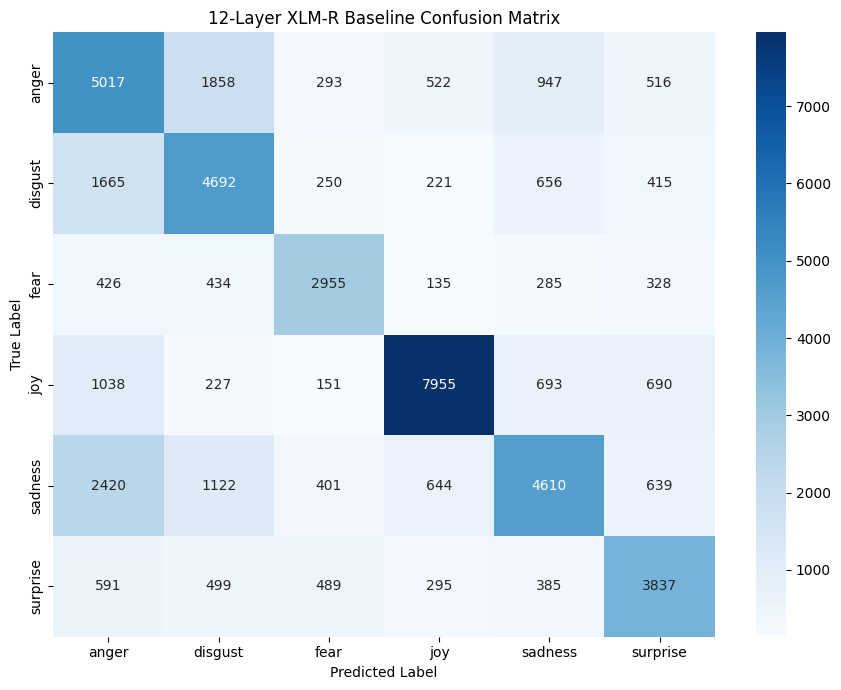

Executed cell #22


In [22]:
# ==========================================================
# CELL 22
# Plot one confusion matrix for the 12-layer baseline
# ==========================================================

print("Starting cell #22")

cm = confusion_matrix(test_metrics["labels"], test_metrics["preds"])

print("Confusion matrix total count:", int(cm.sum()))
print("This total equals the number of flat test samples, not the number of original rows.")

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names,
    cmap="Blues"
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("12-Layer XLM-R Baseline Confusion Matrix")
plt.tight_layout()
plt.show()

print("Executed cell #22")

In [23]:
# ==========================================================
# CELL 23
# Print final baseline model information
# ==========================================================

print("Starting cell #23")

base_baseline = get_base_model(baseline_model)

total_params = sum(p.numel() for p in base_baseline.parameters())
trainable_params = sum(p.numel() for p in base_baseline.parameters() if p.requires_grad)

if os.path.exists(baseline_best_path):
    model_size_mb = os.path.getsize(baseline_best_path) / (1024 ** 2)
else:
    model_size_mb = None

print("\n================ BASELINE MODEL INFO ================")
print("Model:", BASELINE_MODEL_NAME)
print("Architecture: full 12-layer XLM-RoBERTa-base classifier")
print("Training loss: CE + row alignment + supervised contrastive loss")
print("Knowledge distillation: No")
print("Student compression: No")
print("Best checkpoint:", baseline_best_path)
if model_size_mb is not None:
    print(f"Checkpoint size: {model_size_mb:.2f} MB")
print("Total parameters:", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")
print("=====================================================")

print("Executed cell #23")

Starting cell #23

================ BASELINE MODEL INFO ================
Model: xlm-roberta-base
Architecture: full 12-layer XLM-RoBERTa-base classifier
Training loss: CE + row alignment + supervised contrastive loss
Knowledge distillation: No
Student compression: No
Best checkpoint: /kaggle/working/baseline_12layer_xlmr_fair_comparison/best_baseline_12layer.pt
Checkpoint size: 1058.50 MB
Total parameters: 277,457,670
Trainable parameters: 277,457,670
Executed cell #23
